# Individual Manifold Analysis via UMAP

## Mathematical Context

Unlike the global embedding (which compresses all 50,750 snapshots into a single space to see macro-transitions), this notebook computes a **separate, independent UMAP manifold for each of the 25 experimental runs**. 

By processing each run individually (2,030 snapshots):
1. **Local Topology**: UMAP can strictly optimize the topological shape of that specific forcing regime without being distorted by the mathematical "pull" of completely disconnected flow regimes.
2. **Hyperparameters**: Because the dataset size drops from 50k to 2k points, we lower the `n_neighbors` parameter from 50 to 20. This prevents UMAP from over-smoothing the manifold, allowing us to see the crisp 20-phase cyclic structures inherent to the actuation frequency.
3. **Memory & PCA**: A single run (2,030 snapshots $\times$ 171,622 features) occupies about 1.4 GB in RAM. We first apply PCA (500 components) to compress the dataset and filter out isotropic turbulent noise, saving these PCA scores to a dedicated folder. Then, we feed the robust PCA scores into UMAP to accelerate convergence and reduce dimensions to 3.


In [2]:
import numpy as np
import os
import time
import gc
from sklearn.decomposition import PCA

os.makedirs('pca_data', exist_ok=True)
n_pca_components = 500
random_state = 42
runs_to_process = range(1, 26)

print("--- Computing Individual PCA for each run ---")
start_time = time.time()

for run_idx in runs_to_process:
    data_path = f"compressed_data/RUN{run_idx}_PIV_compressed.npz"
    out_path = f"pca_data/RUN{run_idx}_PCA.npz"
    
    if os.path.exists(out_path):
        print(f"PCA for RUN {run_idx} already exists. Skipping.")
        continue
        
    if not os.path.exists(data_path):
        continue
        
    print(f"Processing RUN {run_idx} PCA...")
    
    # Load single run
    d = np.load(data_path)
    u, v = d['u'], d['v']
    nt = u.shape[0]
    
    # Flatten the spatial dimensions
    X_full = np.empty((nt, 2 * u.shape[1] * u.shape[2]), dtype=np.float32)
    X_full[:, :u.shape[1]*u.shape[2]] = u.reshape(nt, -1)
    X_full[:, u.shape[1]*u.shape[2]:] = v.reshape(nt, -1)
    
    del u, v, d
    gc.collect()
    
    # Compute PCA to denoise and compress
    pca = PCA(n_components=n_pca_components, random_state=random_state)
    X_pca = pca.fit_transform(X_full)
    explained_variance = pca.explained_variance_ratio_
    
    del X_full
    gc.collect()
    
    # Save the scores and the explained variance
    np.savez_compressed(out_path, scores=X_pca, explained_variance_ratio=explained_variance)

print(f"\nAll PCA computations finished in {(time.time() - start_time)/60:.1f} minutes.")


--- Computing Individual PCA for each run ---
Processing RUN 1 PCA...
Processing RUN 2 PCA...
Processing RUN 3 PCA...
Processing RUN 4 PCA...
Processing RUN 5 PCA...
Processing RUN 6 PCA...
Processing RUN 7 PCA...
Processing RUN 8 PCA...
Processing RUN 9 PCA...
Processing RUN 10 PCA...
Processing RUN 11 PCA...
Processing RUN 12 PCA...
Processing RUN 13 PCA...
Processing RUN 14 PCA...
Processing RUN 15 PCA...
Processing RUN 16 PCA...
Processing RUN 17 PCA...
Processing RUN 18 PCA...
Processing RUN 19 PCA...
Processing RUN 20 PCA...
Processing RUN 21 PCA...
Processing RUN 22 PCA...
Processing RUN 23 PCA...
Processing RUN 24 PCA...
Processing RUN 25 PCA...

All PCA computations finished in 13.4 minutes.


In [3]:
import numpy as np
import os
import time
import umap

os.makedirs('umap_data', exist_ok=True)

n_umap_components = 3
n_neighbors = 20
min_dist = 0.1
random_state = 42

runs_to_process = range(1, 26)

st_info = {
    1: 0.0, 2: 0.05, 3: 0.10, 4: 0.15, 5: 0.20, 6: 0.25, 7: 0.30, 8: 0.35, 9: 0.40, 
    10: 0.45, 11: 0.50, 12: 0.55, 13: 0.60, 14: 0.65, 15: 0.70, 16: 0.75, 17: 0.80, 
    18: 0.85, 19: 0.90, 20: 0.95, 21: 1.00, 22: 1.05, 23: 1.10, 24: 1.15, 25: 1.20
}

output_path = "umap_data/individual_umaps_3D.npz"

if os.path.exists(output_path):
    print("\nIndividual UMAPs already computed. Skipping computation.")
else:
    print("--- Computing Individual UMAPs from PCA data ---")
    start_time = time.time()
    
    all_embeddings = {}
    
    for run_idx in runs_to_process:
        pca_path = f"pca_data/RUN{run_idx}_PCA.npz"
        if not os.path.exists(pca_path):
            continue
            
        print(f"Computing UMAP for RUN {run_idx}...")
        
        # Load PCA scores
        d = np.load(pca_path)
        X_pca = d['scores']
        
        # Initialize and fit UMAP
        reducer = umap.UMAP(n_components=n_umap_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
        X_umap = reducer.fit_transform(X_pca)
        
        all_embeddings[str(run_idx)] = X_umap
        
    computation_time = time.time() - start_time
    print(f"\nAll UMAP computations finished in {computation_time/60:.1f} minutes.")
    
    # Save the dictionary of arrays
    np.savez_compressed(output_path, **all_embeddings)
    print(f"Saved results to {output_path}")


--- Computing Individual UMAPs from PCA data ---
Computing UMAP for RUN 1...


c:\Users\alefo\Anaconda3\envs\influentia\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for RUN 2...


c:\Users\alefo\Anaconda3\envs\influentia\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\alefo\Anaconda3\envs\influentia\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Computing UMAP for RUN 3...


...

Computing UMAP for RUN 24...


c:\Users\alefo\Anaconda3\envs\influentia\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP for RUN 25...


c:\Users\alefo\Anaconda3\envs\influentia\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



All UMAP computations finished in 5.1 minutes.
Saved results to umap_data/individual_umaps_3D.npz


C:\Users\alefo\AppData\Local\Temp\ipykernel_22212\3429502512.py:48: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



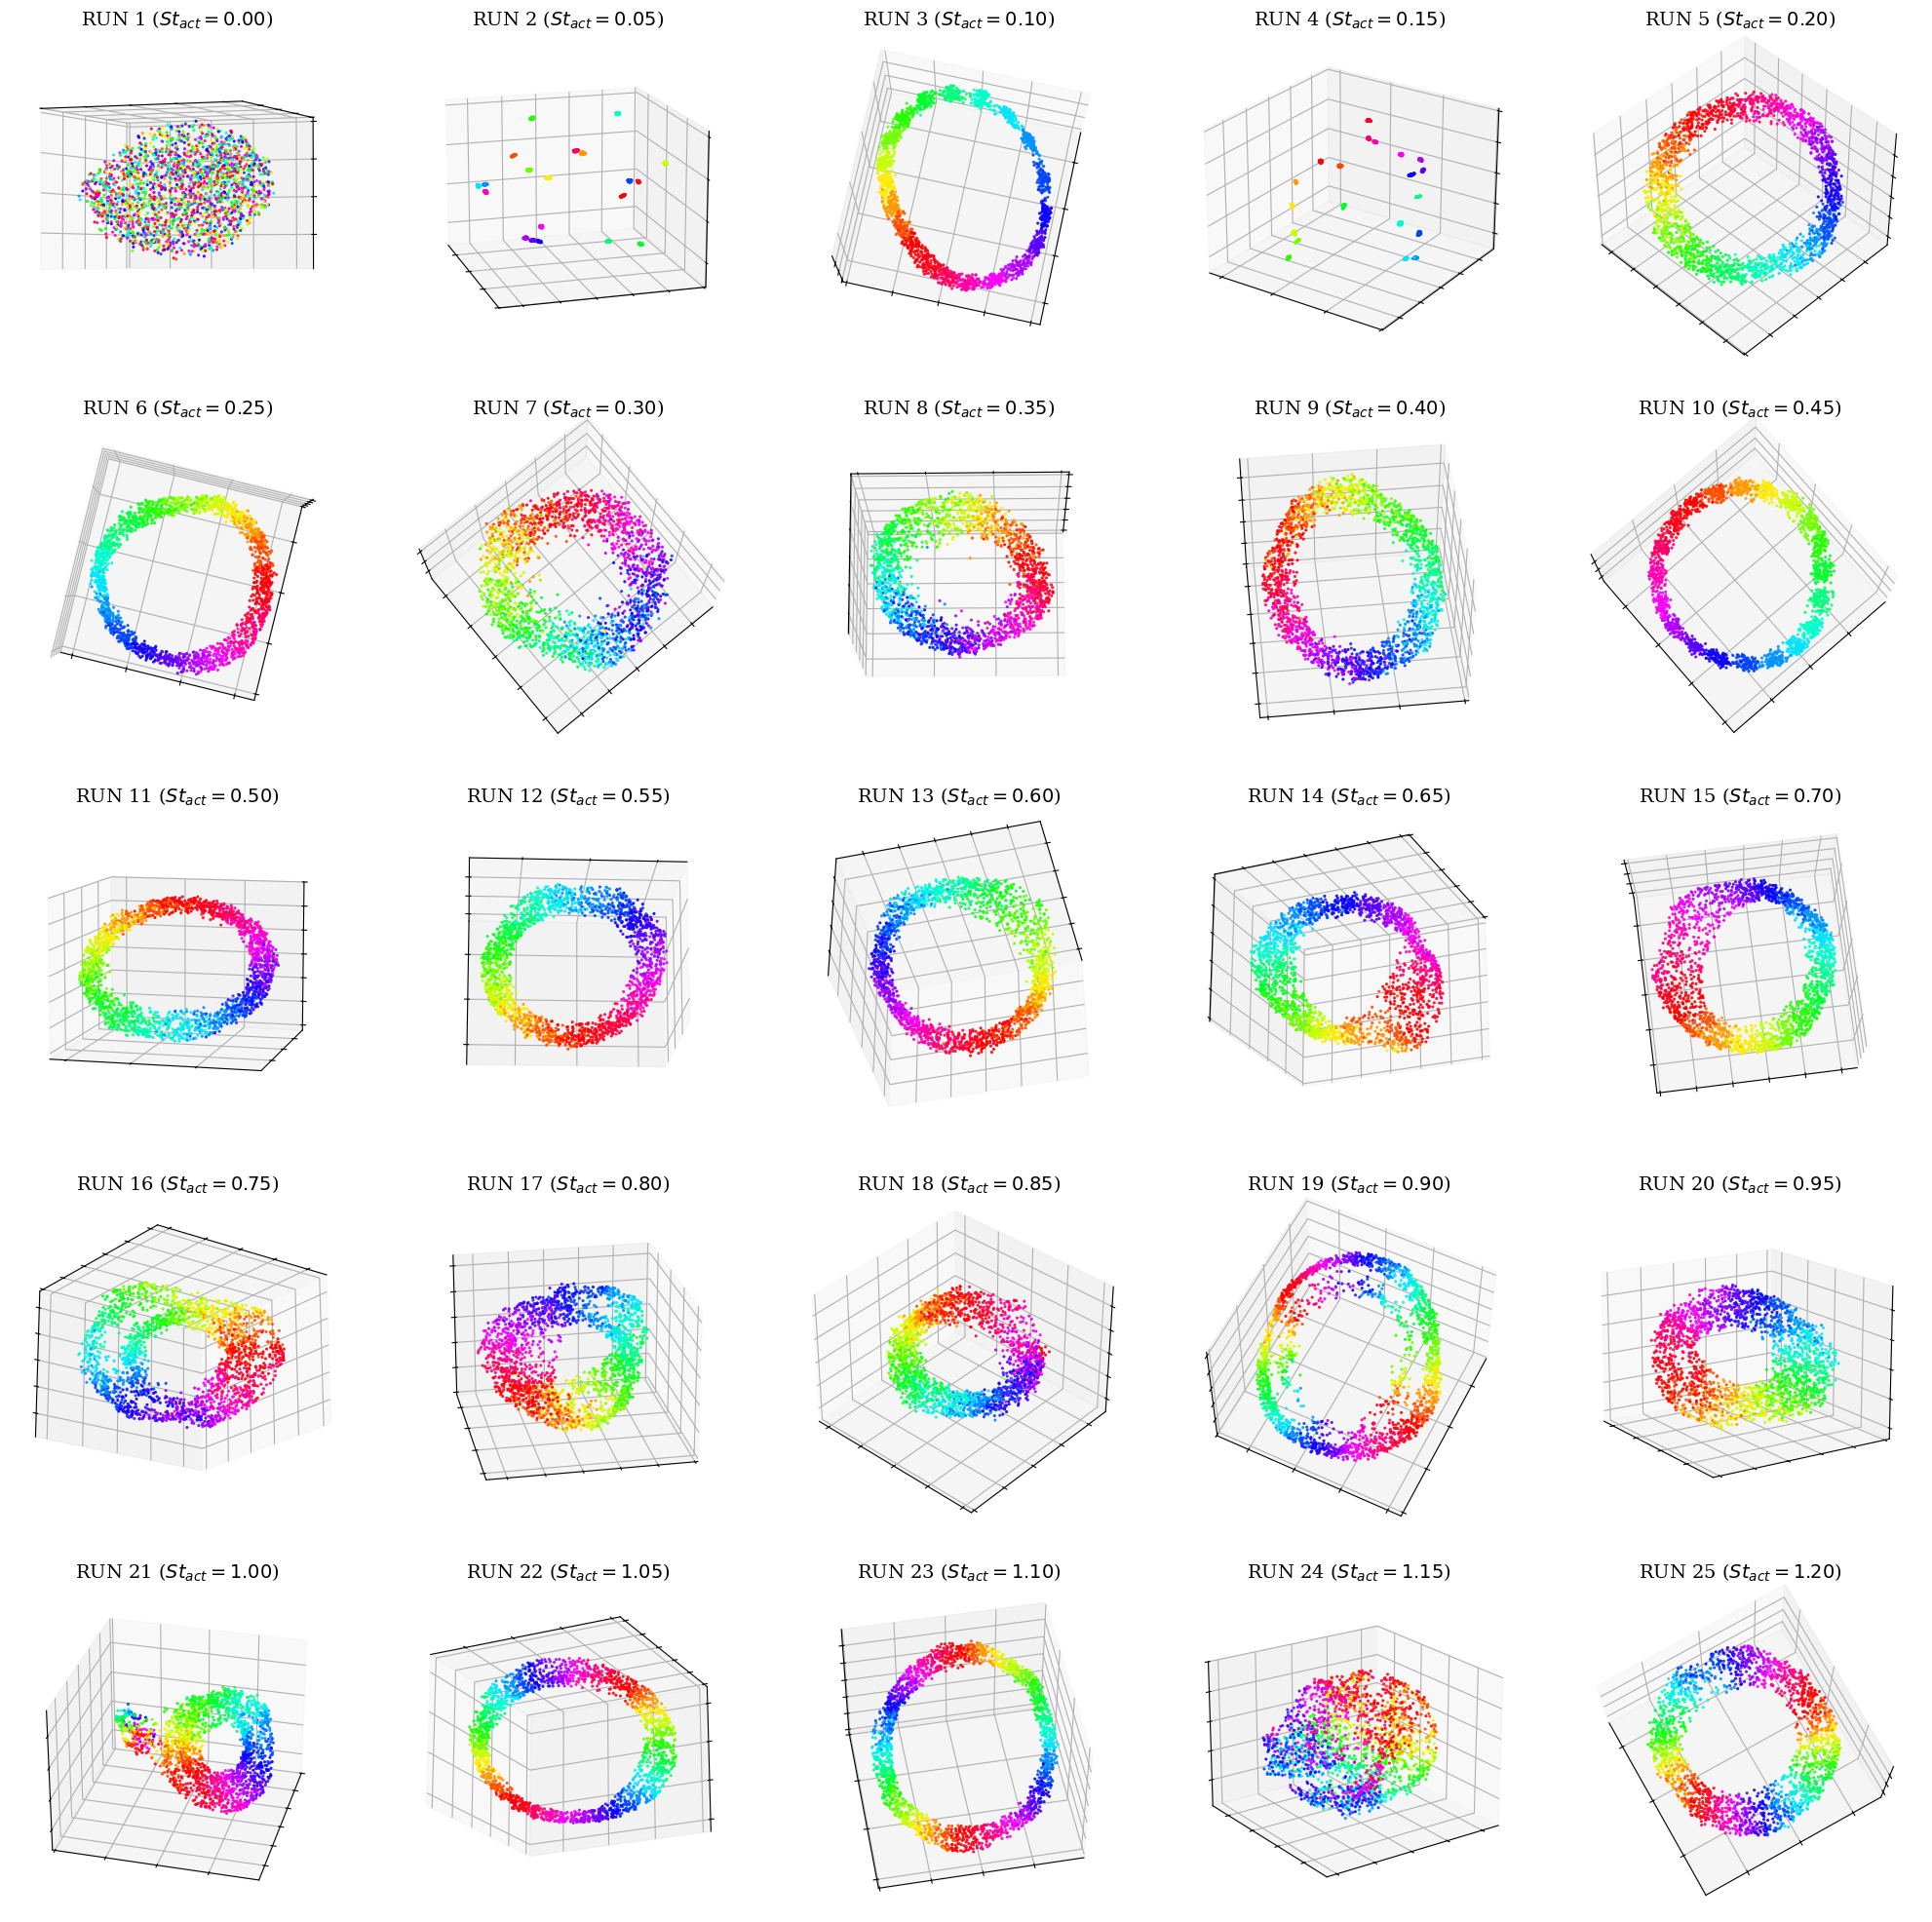

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

os.makedirs('figures', exist_ok=True)

# Load the computed UMAPs
data = np.load("umap_data/individual_umaps_3D.npz")
unique_runs = [int(k) for k in data.files]
unique_runs.sort()

fig = plt.figure(figsize=(25, 25))

for i, run in enumerate(unique_runs):
    ax = fig.add_subplot(5, 5, i + 1, projection='3d')
    
    run_emb = data[str(run)]
    st_val = st_info[run]
    
    # Calculate phase (0 to 19)
    phase = np.arange(len(run_emb)) % 20
    
    ax.scatter(run_emb[:, 0], run_emb[:, 1], run_emb[:, 2], 
               c=phase, cmap='hsv', vmin=0, vmax=19, 
               s=5, alpha=0.9, edgecolors='none')
               
    # Outlier-immune camera orientation
    p_low = np.percentile(run_emb, 20, axis=0)
    p_high = np.percentile(run_emb, 80, axis=0)
    
    core_mask = np.all((run_emb >= p_low) & (run_emb <= p_high), axis=1)
    core_emb = run_emb[core_mask]
    
    if len(core_emb) > 10:
        pca_3d = PCA(n_components=3)
        pca_3d.fit(core_emb)
        x, y, z = pca_3d.components_[2]
        elev = np.degrees(np.arcsin(z))
        azim = np.degrees(np.arctan2(y, x))
        ax.view_init(elev=elev, azim=azim)
    
    ax.set_title(f"RUN {run} ($St_{{act}}={st_val:.2f}$)", fontsize=14)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

plt.tight_layout()
plt.savefig('figures/individual_umaps_3D_grid.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Choose which run you want to explore interactively!
run_to_plot = 24

if str(run_to_plot) in data:
    emb_single = data[str(run_to_plot)]

    df_single = pd.DataFrame({
        'UMAP 1': emb_single[:, 0],
        'UMAP 2': emb_single[:, 1],
        'UMAP 3': emb_single[:, 2],
        'Phase': np.arange(len(emb_single)) % 20
    })

    # Shuffle the dataframe so no specific phase dominates the top layer
    df_single = df_single.sample(frac=1, random_state=42).reset_index(drop=True)

    fig = px.scatter_3d(
        df_single, 
        x='UMAP 1', 
        y='UMAP 2', 
        z='UMAP 3',
        color='Phase',
        color_continuous_scale='hsv',
        opacity=0.8
    )

    fig.update_layout(
        title=f"Individual 3D UMAP Manifold - RUN {run_to_plot} (Colored by Phase)",
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()
else:
    print(f"Data for RUN {run_to_plot} not found.")
